In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic-machine-learning-from-disaster/train.csv
/kaggle/input/titanic-machine-learning-from-disaster/test.csv


In [3]:
import pandas as pd

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/test.csv')

print(train_data.head())
print(test_data.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print(train_data.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
# Eliminar una columna del DataFrame
train_data = train_data.drop('Cabin', axis=1)


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [8]:
# Calcular la media de la columna Age, ignorando valores faltantes
mean_age = train_data['Age'].mean()

# Imputar los valores faltantes en la columna Age con la media
train_data['Age'] = train_data['Age'].fillna(mean_age)

# Resultado: lleno los datos faltantes con la media
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [9]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [10]:
# Eliminar una columna del DataFrame
ytrain = train_data['Survived']
train_data = train_data.drop(['Name','Survived'], axis=1)
train_data = train_data.drop('Ticket', axis=1)
train_data = train_data.drop('PassengerId', axis=1)
# Mostrar resultado
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [11]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
encoder_ = OrdinalEncoder()
lista = ["Sex","Embarked"]
train_data[lista] = encoder_.fit_transform(train_data[lista])
imputer_ = SimpleImputer(strategy='most_frequent')
train_data[['Age','Embarked']] = imputer_.fit_transform(train_data[['Age','Embarked']])

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    float64
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 48.9 KB


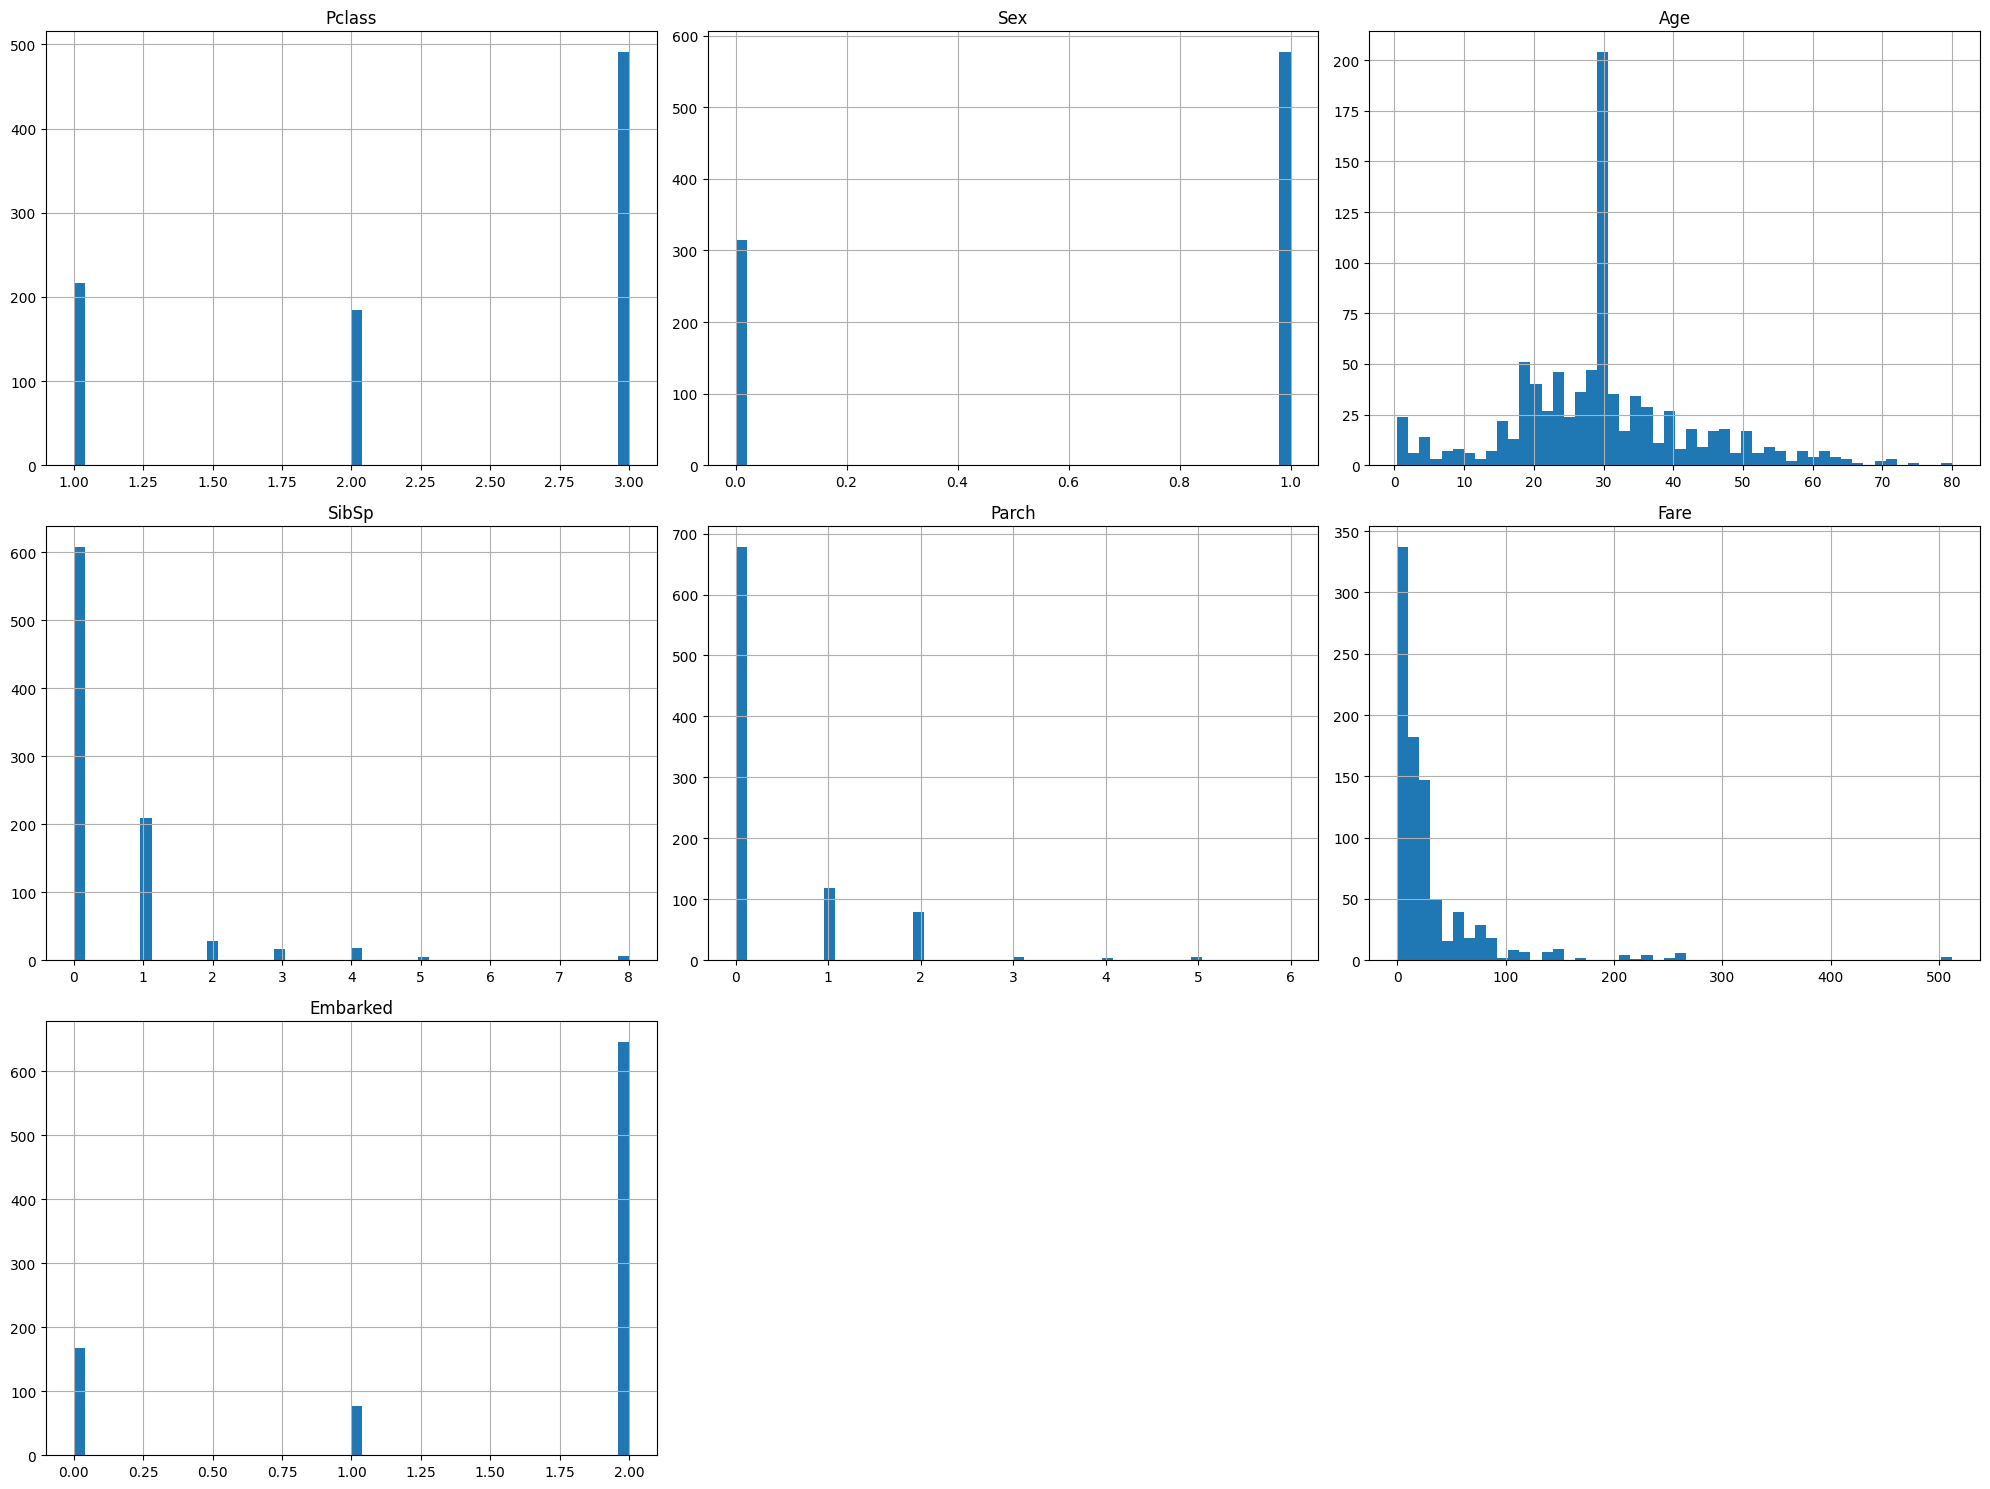

In [13]:
import matplotlib.pyplot as plt

train_data.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

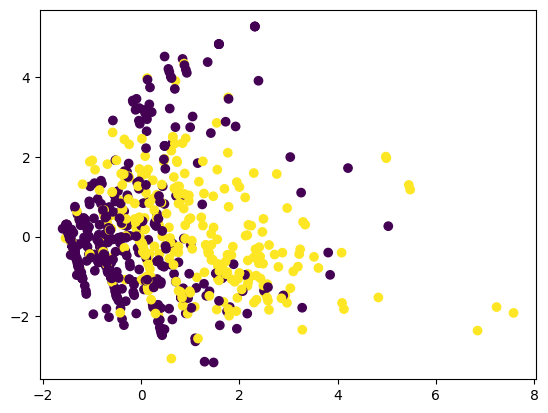

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sca_ = StandardScaler()
red_ = PCA(n_components = 2)
ztrain = red_.fit_transform(sca_.fit_transform(train_data))
ztrain.shape
plt.scatter(ztrain[:,0],ztrain[:,1],c=ytrain)

✅ Accuracy del modelo: 0.791

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.82      0.83       165
   Sobrevivió       0.72      0.74      0.73       103

     accuracy                           0.79       268
    macro avg       0.78      0.78      0.78       268
 weighted avg       0.79      0.79      0.79       268



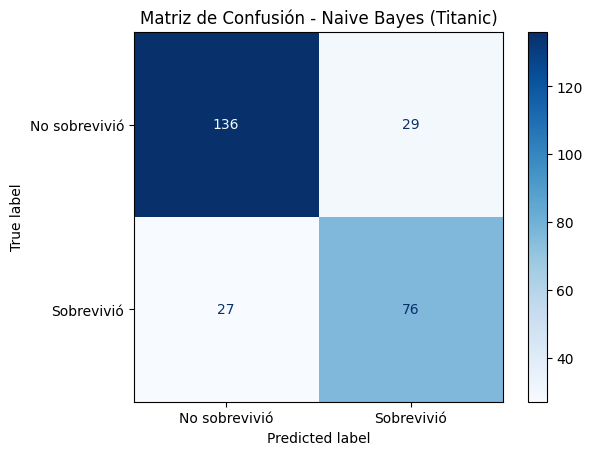

In [15]:
# ======================================================
# 🧠 Clasificador Naive Bayes - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (importante para NB)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo Naive Bayes
# ------------------------------------------------------
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = nb_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Naive Bayes (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.791

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.82      0.85      0.83       165
   Sobrevivió       0.75      0.69      0.72       103

     accuracy                           0.79       268
    macro avg       0.78      0.77      0.78       268
 weighted avg       0.79      0.79      0.79       268



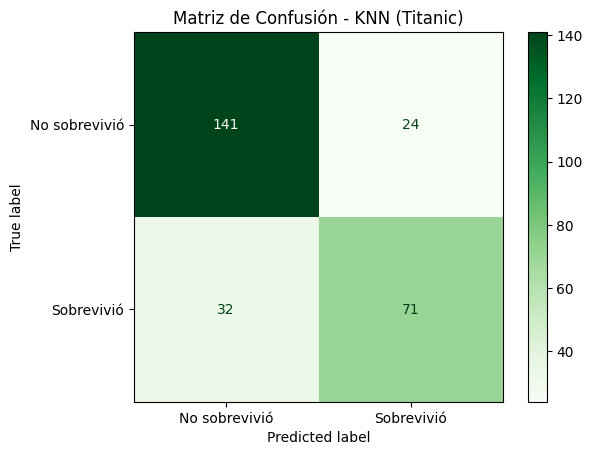

In [16]:
# ======================================================
# 🤖 Clasificador KNN - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (KNN depende de distancias)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo KNN
# ------------------------------------------------------
# k=5 suele ser un buen punto de partida
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = knn_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Greens")
plt.title("Matriz de Confusión - KNN (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.85      0.84       165
   Sobrevivió       0.75      0.72      0.73       103

     accuracy                           0.80       268
    macro avg       0.79      0.78      0.79       268
 weighted avg       0.80      0.80      0.80       268



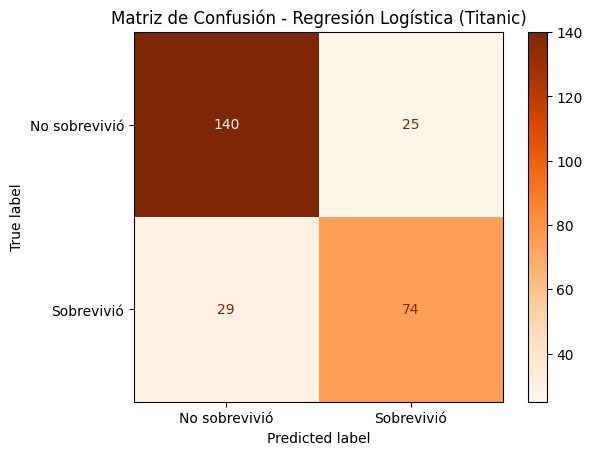

In [17]:
# ======================================================
# 📈 Clasificador Regresión Logística - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo de Regresión Logística
# ------------------------------------------------------
log_model = LogisticRegression(max_iter=1000, solver='lbfgs')
log_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = log_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Oranges")
plt.title("Matriz de Confusión - Regresión Logística (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.81      0.88      0.84       165
   Sobrevivió       0.78      0.66      0.72       103

     accuracy                           0.80       268
    macro avg       0.79      0.77      0.78       268
 weighted avg       0.80      0.80      0.79       268



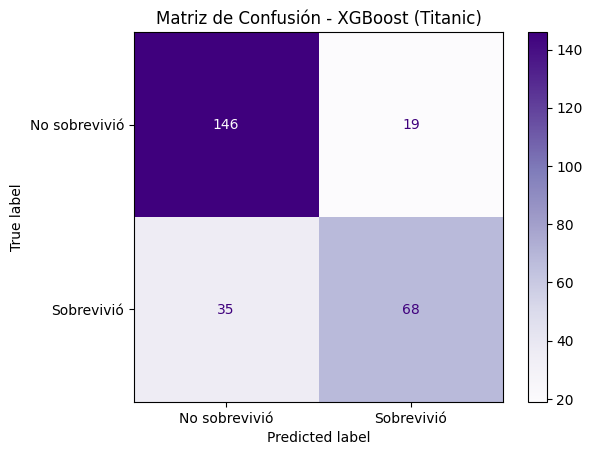

In [18]:
# ======================================================
# 🚀 Clasificador XGBoost - Titanic
# ======================================================

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (opcional pero recomendable)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo XGBoost
# ------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=200,        # número de árboles
    learning_rate=0.05,      # tasa de aprendizaje
    max_depth=4,             # profundidad máxima de los árboles
    subsample=0.8,           # porcentaje de muestras por árbol
    colsample_bytree=0.8,    # porcentaje de variables por árbol
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # métrica para evitar warnings
)
xgb_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = xgb_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - XGBoost (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.79      0.92      0.85       165
   Sobrevivió       0.82      0.61      0.70       103

     accuracy                           0.80       268
    macro avg       0.80      0.76      0.77       268
 weighted avg       0.80      0.80      0.79       268



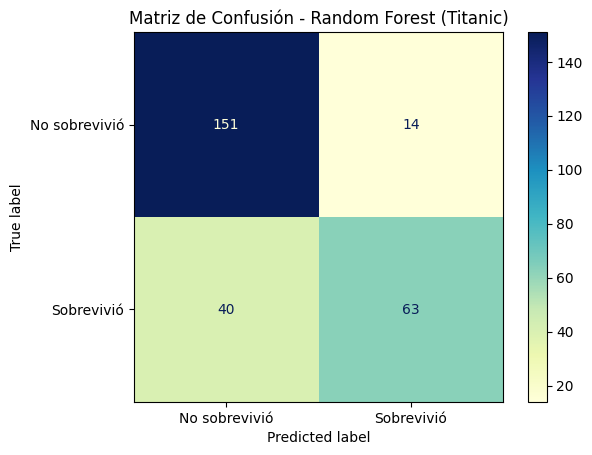

In [19]:
# ======================================================
# 🌲 Clasificador Random Forest - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (opcional en árboles, pero mantiene coherencia)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo Random Forest
# ------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,     # número de árboles
    max_depth=6,          # profundidad máxima de cada árbol
    min_samples_split=4,  # división mínima para crear ramas
    min_samples_leaf=2,   # tamaño mínimo de las hojas
    random_state=42,
    n_jobs=-1             # usa todos los núcleos del CPU
)
rf_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = rf_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="YlGnBu")
plt.title("Matriz de Confusión - Random Forest (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.8022

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.81      0.88      0.85       165
   Sobrevivió       0.78      0.68      0.73       103

     accuracy                           0.80       268
    macro avg       0.80      0.78      0.79       268
 weighted avg       0.80      0.80      0.80       268



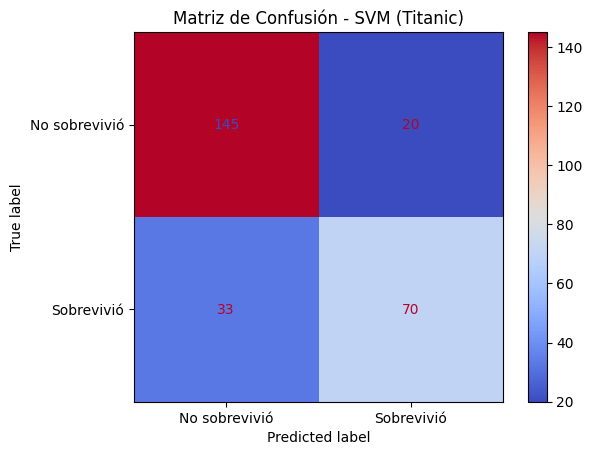

In [20]:
# ======================================================
# ⚙️ Clasificador SVM (Support Vector Machine) - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (SVM depende de distancias)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo SVM
# ------------------------------------------------------
svm_model = SVC(
    kernel='rbf',         # 'rbf' = radial basis function, ideal para relaciones no lineales
    C=1.0,                # controla la penalización por errores
    gamma='scale',        # define la influencia de cada punto
    probability=True,     # permite calcular probabilidades posteriores
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = svm_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="coolwarm")
plt.title("Matriz de Confusión - SVM (Titanic)")
plt.show()


In [22]:
!python -c "import cudf, cuml; print('✅ RAPIDS está disponible y listo para usar')"

✅ RAPIDS está disponible y listo para usar


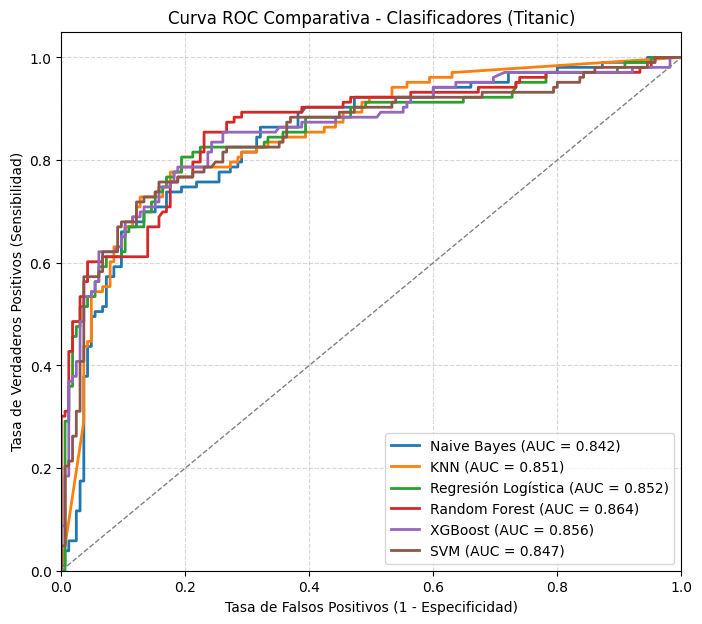

In [24]:
# ======================================================
# 🎯 Curvas ROC - Comparación de Clasificadores (Titanic)
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------
# 1️⃣ División del dataset
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# Escalar (necesario para KNN, SVM, Regresión Logística)
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 2️⃣ Inicializar clasificadores
# ------------------------------------------------------
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance'),
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                              n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
}

# ------------------------------------------------------
# 3️⃣ Calcular curvas ROC y AUC
# ------------------------------------------------------
plt.figure(figsize=(8, 7))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    # Probabilidad de pertenecer a la clase positiva
    y_score = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# ------------------------------------------------------
# 4️⃣ Gráfico general
# ------------------------------------------------------
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC Comparativa - Clasificadores (Titanic)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
